In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset, Dataset
import random
import csv
import pandas as pd
import torch.nn.utils as utils
#from torchvision.utils import make_grid
#from torch.autograd.functional import jacobian
#from torch.autograd.functional import vjp

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Get the Data, including the subset/augmented data

In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(-0.00,), std=(1.00,))]) #was mean -0.5 and std 1.0 at round 1.

target_transform_one_hot_f = transforms.Lambda(lambda y: F.one_hot(torch.tensor(y), num_classes=10).float())

batch_size = 128 #512

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform,
                                        target_transform=target_transform_one_hot_f)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)


testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform,
                                       target_transform=target_transform_one_hot_f)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

In [ ]:
'''class StiefelKernel(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        #self.weight = ManifoldParameter(
        #    torch.randn(1, 1, kernel_size, kernel_size),
        #    manifold=Stiefel()
        #)
        self.weight = mnn.Parameter(
            torch.randn(1, 1, kernel_size, kernel_size),
            manifold=mnn.Stiefel(kernel_size, kernel_size)
        )

    def forward(self, x):
        # x in this case is the output of the score_at_clean_image function.
        return F.conv2d(x, self.weight, padding=7 // 2) #kernel_size=7'''

'''class StiefelKernel(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        # Define a 2D weight matrix on the Stiefel manifold (kernel_size x kernel_size)
        self.weight = mnn.Parameter(
            torch.randn(kernel_size, kernel_size),
            manifold=mnn.Stiefel(kernel_size, kernel_size)
        )

    def forward(self, x):
        # Reshape to conv2d shape: (out_channels, in_channels, kernel_h, kernel_w)
        w = self.weight.view(1, 1, 7, 7)  # or kernel_size
        return F.conv2d(x, w, padding=7 // 2)'''


class StiefelKernel(nn.Module):
    def __init__(self, kernel_size=7, use_stiefel=True):
        super().__init__()

        self.kernel_size = kernel_size
        self.use_stiefel = use_stiefel

        if self.use_stiefel:
            #if not use_mctorch_available:
            #    raise ImportError("McTorch is not installed but use_stiefel=True was requested.")
            self.weight = mnn.Parameter(
                torch.randn(kernel_size, kernel_size),
                manifold=mnn.Stiefel(kernel_size, kernel_size)
            )
        else:
            # Standard PyTorch learnable weight
            self.weight = nn.Parameter(
                torch.randn(kernel_size, kernel_size)
            )

            #GTkernel = torch.tensor([
            #               [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)],
            #               [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
            #               [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
            #               [6.347132048*10**(-20),3.245999951*10**(-8),0.1388299687,-0.5596471072,0.1388299687,3.245999951*10**(-8),6.347132048*10**(-20)],
            #               [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
            #               [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
            #               [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)]])

            #self.weight = nn.Parameter(GTkernel)

    def forward(self, x):
        # Reshape to conv2d shape: (out_channels, in_channels, kernel_h, kernel_w)
        #w = self.weight.view(1, 1, self.kernel_size, self.kernel_size)
        #return F.conv2d(x, w, padding=self.kernel_size // 2)
        w = self.weight #/ (self.weight.norm(p='fro') + 1e-8)
        w = w.view(1, 1, self.kernel_size, self.kernel_size)
        return F.conv2d(x, w, padding=self.kernel_size // 2)



In [ ]:
def gaussblurIG(img):
    from torch.nn.functional import conv2d, grid_sample, interpolate, pad as torch_pad
    #this is a fixed kernel of size (7,7)
    kernel_size = [7,7]

    kernel = torch.tensor([
                           [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)],
                           [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
                           [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
                           [6.347132048*10**(-20),3.245999951*10**(-8),0.1388299687,-0.5596471072,0.1388299687,3.245999951*10**(-8),6.347132048*10**(-20)],
                           [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
                           [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
                           [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)]])

    kernel = kernel.reshape((img.shape[-3],1,kernel.shape[0],kernel.shape[1])).to(device)
    # borrowing from torchvision (_functional)
    '''def _cast_squeeze_out(img: Tensor, need_cast: bool, need_squeeze: bool, out_dtype: torch.dtype) -> Tensor:
        if need_squeeze:
            img = img.squeeze(dim=0)

        if need_cast:
            if out_dtype in (torch.uint8, torch.int8, torch.int16, torch.int32, torch.int64):
                # it is better to round before cast
                img = torch.round(img)
            img = img.to(out_dtype)

        return img'''


    #having now defined the kernel, we use it.
    # padding = (left, right, top, bottom)
    #padding = [kernel_size[0] // 2, kernel_size[0] // 2, kernel_size[1] // 2, kernel_size[1] // 2]
    #img = torch_pad(img, padding, mode="reflect")
    #img = transforms.ToTensor()
    img = conv2d(img, kernel, padding='same') #, groups=img.shape[-3])

    #img = _cast_squeeze_out(img, need_cast, need_squeeze, out_dtype)
    return img

In [ ]:
def EstimatedgaussblurIG(img, kernel):
    from torch.nn.functional import conv2d, grid_sample, interpolate, pad as torch_pad
    #this is a fixed kernel of size (7,7)
    kernel_size = [kernel.shape[0],kernel.shape[1]] #[7,7]

    #kernel = torch.tensor([
    #                       [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)],
    #                       [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
    #                       [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
    #                       [6.347132048*10**(-20),3.245999951*10**(-8),0.1388299687,-0.5596471072,0.1388299687,3.245999951*10**(-8),6.347132048*10**(-20)],
    #                       [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
    #                       [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
    #                       [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)]])

    kernel = kernel.reshape((img.shape[-3],1,kernel.shape[0],kernel.shape[1])).to(device)
    # borrowing from torchvision (_functional)
    '''def _cast_squeeze_out(img: Tensor, need_cast: bool, need_squeeze: bool, out_dtype: torch.dtype) -> Tensor:
        if need_squeeze:
            img = img.squeeze(dim=0)

        if need_cast:
            if out_dtype in (torch.uint8, torch.int8, torch.int16, torch.int32, torch.int64):
                # it is better to round before cast
                img = torch.round(img)
            img = img.to(out_dtype)

        return img'''


    #having now defined the kernel, we use it.
    # padding = (left, right, top, bottom)
    #padding = [kernel_size[0] // 2, kernel_size[0] // 2, kernel_size[1] // 2, kernel_size[1] // 2]
    #img = torch_pad(img, padding, mode="reflect")
    #img = transforms.ToTensor()
    img = conv2d(img, kernel, padding='same') #, groups=img.shape[-3])

    #img = _cast_squeeze_out(img, need_cast, need_squeeze, out_dtype)
    return img

In [ ]:
blurVF = lambda x: gaussblurIG(x)

In [ ]:
def learn_kernel(dataloader, DFmodel, optimizer=optim.Adam, n_epochs=5, criterion=torch.nn.MSELoss(), lr=1e-2):

    model = StiefelKernel(use_stiefel=False).to(device)
    optimizer = optimizer(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        for i, data in enumerate(dataloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device) # we won't use the labels here, actually.
            score_tensor = score_at_clean_image(inputs, 1, DFmodel, alpha_hat) #alpha_hat is global.
            y_pred = model(score_tensor)
            y = torch.zeros_like(score_tensor) # these are the targets we're using, not labels.
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            #if i % 10==0:
            #    print(f"Epoch [{epoch + 1}/{n_epochs}], minibatch [{i}], Loss: {loss.item():.6f}")

        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

    return loss.item(), model

In [ ]:
def learn_kernel2(dataloader, optimizer=optim.Adam, n_epochs=5, criterion=torch.nn.MSELoss(), lr=1e-2):

    model = StiefelKernel(use_stiefel=False, kernel_size=7).to(device)
    optimizer = optimizer(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        for i, data in enumerate(dataloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            #score_tensor = score_at_clean_image(inputs, 1, DFmodel, alpha_hat) #alpha_hat is global.
            y_pred = model(inputs)
            #y = torch.zeros_like(inputs) # these are the targets we're using, not labels.
            loss = criterion(y_pred, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            #if i % 10==0:
            #    print(f"Epoch [{epoch + 1}/{n_epochs}], minibatch [{i}], Loss: {loss.item():.6f}")

        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

    return loss.item(), model

In [ ]:
#theData = transforms.Normalize(mean=(-0.001,), std=(1.001,))(trainset.data.float())
theData = transforms.Normalize(mean=(-0.00,), std=(1.00,))(trainset.data.float())

In [ ]:
# here we'll get the gradients of each.
gradient_list = []
for i in range(60000):
    theselection = theData[i].reshape((1,28,28))
    blurred_copies = [theselection]

    for j in range(1,11):
        blurred_copies.extend([torchvision.transforms.functional.gaussian_blur(theselection, 7, sigma=0.1*j)])
        #blurred_copies.extend([torchvision.transforms.functional.rotate(theselection, angle=15.0*j-90.0)])

    sequence = torch.stack(blurred_copies)
    sequence_grad_at_3 = torch.gradient(sequence, spacing=(0.1,), dim=0)[0][3] #0: original. 1: 0.1. 2: 0.2, etc.
    #sequence_grad_at_3 = torch.gradient(sequence, spacing=(0.1,), dim=0)[0][6] #6: original.
    gradient_list.extend([sequence_grad_at_3])
    if i % 5000==0:
        print("Done: " + str(i))

gradient_list = torch.stack(gradient_list)

Done: 0
Done: 5000
Done: 10000
Done: 15000
Done: 20000
Done: 25000
Done: 30000
Done: 35000
Done: 40000
Done: 45000
Done: 50000
Done: 55000


In [ ]:
# we want to use the gradient_list as the targets and the original data as the input.
class PairedDataset(Dataset):
    def __init__(self, input_dataset, target_tensor):
        self.input_dataset = input_dataset
        self.target_tensor = target_tensor

        assert len(input_dataset) == len(target_tensor), "Input and target lengths must match"

    def __len__(self):
        return len(self.input_dataset)

    def __getitem__(self, idx):
        x, _ = self.input_dataset[idx]  # Ignore original label
        y = self.target_tensor[idx]
        return x, y


In [ ]:
#gradient_loader = torch.utils.data.DataLoader(gradient_list, batch_size=64,
#                                          shuffle=True, num_workers=2)

In [ ]:
paired_dataset = PairedDataset(trainset, gradient_list)

paired_loader = torch.utils.data.DataLoader(
    paired_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)


In [ ]:
#result = learn_kernel2(paired_loader, optimizer=optim.Adam, n_epochs=10, criterion=torch.nn.L1Loss(), lr=1e-2)

Epoch 1/10, Loss: 7.1239
Epoch 2/10, Loss: 7.0799
Epoch 3/10, Loss: 6.3441
Epoch 4/10, Loss: 5.6202
Epoch 5/10, Loss: 5.2774
Epoch 6/10, Loss: 4.7970
Epoch 7/10, Loss: 4.4542
Epoch 8/10, Loss: 4.3707
Epoch 9/10, Loss: 3.9657
Epoch 10/10, Loss: 3.9543


In [ ]:
#print(result[1].weight)

Parameter containing:
tensor([[ 1.5523e-02, -5.8497e-02,  1.2880e-01, -1.7083e-01,  8.9127e-02,
         -1.5090e-02,  1.7552e-03],
        [-5.0051e-02,  7.3337e-01, -3.2593e+00,  4.1772e+00, -1.2457e+00,
          4.1912e-02,  1.2968e-03],
        [ 6.7741e-02, -2.5450e+00,  3.2426e+01, -6.0543e+00,  2.2335e+01,
         -3.3761e-02, -1.4709e-02],
        [-1.2737e-01,  2.8465e+00, -5.7660e+00, -8.7108e+01, -5.7132e+00,
          2.8786e+00, -1.2317e-01],
        [-7.1632e-03, -3.9197e-02,  2.2184e+01, -5.7826e+00,  3.2182e+01,
         -2.5226e+00,  7.2640e-02],
        [ 1.0606e-03,  4.3818e-02, -1.1497e+00,  3.8410e+00, -3.0871e+00,
          7.1395e-01, -5.1952e-02],
        [ 2.4702e-03, -1.4244e-02,  5.7923e-02, -1.0823e-01,  9.1191e-02,
         -5.4552e-02,  1.2784e-02]], requires_grad=True)


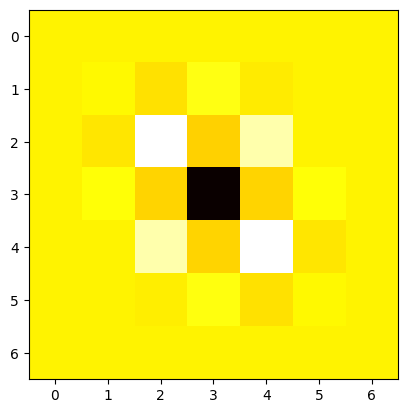

In [ ]:
#plt.imshow(result[1].weight.detach().cpu(), cmap='hot')
#plt.show()

In [ ]:
result2 = learn_kernel2(paired_loader, optimizer=optim.Adam, n_epochs=50, criterion=torch.nn.L1Loss(), lr=1e-2)

Epoch 1/50, Loss: 7.6090
Epoch 2/50, Loss: 6.4938
Epoch 3/50, Loss: 6.5777
Epoch 4/50, Loss: 5.8112
Epoch 5/50, Loss: 5.5357
Epoch 6/50, Loss: 5.2290
Epoch 7/50, Loss: 4.7812
Epoch 8/50, Loss: 4.6913
Epoch 9/50, Loss: 4.0735
Epoch 10/50, Loss: 3.5822
Epoch 11/50, Loss: 3.4384
Epoch 12/50, Loss: 3.2084
Epoch 13/50, Loss: 3.0163
Epoch 14/50, Loss: 2.6962
Epoch 15/50, Loss: 2.3664
Epoch 16/50, Loss: 1.9529
Epoch 17/50, Loss: 1.4909
Epoch 18/50, Loss: 1.2249
Epoch 19/50, Loss: 0.9850
Epoch 20/50, Loss: 0.6357
Epoch 21/50, Loss: 0.3417
Epoch 22/50, Loss: 0.0236
Epoch 23/50, Loss: 0.0251
Epoch 24/50, Loss: 0.0145
Epoch 25/50, Loss: 0.0121
Epoch 26/50, Loss: 0.0144
Epoch 27/50, Loss: 0.0315
Epoch 28/50, Loss: 0.0032
Epoch 29/50, Loss: 0.0145
Epoch 30/50, Loss: 0.0137
Epoch 31/50, Loss: 0.0175
Epoch 32/50, Loss: 0.0451
Epoch 33/50, Loss: 0.0185
Epoch 34/50, Loss: 0.0253
Epoch 35/50, Loss: 0.0144
Epoch 36/50, Loss: 0.0157
Epoch 37/50, Loss: 0.0280
Epoch 38/50, Loss: 0.0175
Epoch 39/50, Loss: 0.

In [ ]:
print(result2[1].weight)

Parameter containing:
tensor([[ 4.3453e-03,  2.3502e-03,  1.0135e-03,  4.8969e-04, -8.2834e-05,
          6.3323e-05,  4.3814e-04],
        [ 2.9548e-03,  1.4775e-03,  1.9037e-03,  5.6810e-03,  6.2964e-04,
          5.4468e-05,  4.4191e-04],
        [ 2.0712e-03,  1.5883e-03,  2.0819e+00,  4.7331e+01,  2.0800e+00,
         -1.0390e-05,  3.7034e-04],
        [ 1.2987e-03,  5.0125e-03,  4.7331e+01, -1.9765e+02,  4.7330e+01,
          4.1723e-03,  5.4749e-04],
        [ 1.0614e-03,  1.2598e-03,  2.0810e+00,  4.7330e+01,  2.0803e+00,
          8.2176e-04,  6.9152e-04],
        [ 1.5143e-03,  1.3332e-03,  1.7076e-03,  5.2390e-03,  1.0780e-03,
          3.9368e-04,  4.8242e-04],
        [ 2.1391e-03,  1.6021e-03,  1.2657e-03,  1.2472e-03,  8.6678e-04,
          3.2045e-04,  5.8598e-05]], requires_grad=True)


In [ ]:
GTkernel = torch.tensor([
                           [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)],
                           [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
                           [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
                           [6.347132048*10**(-20),3.245999951*10**(-8),0.1388299687,-0.5596471072,0.1388299687,3.245999951*10**(-8),6.347132048*10**(-20)],
                           [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
                           [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
                           [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)]])

In [ ]:
n1 = torch.dot(result2[1].weight.detach().reshape((49,)), GTkernel.reshape((49,)))
d1 = torch.dot(GTkernel.reshape((49,)), GTkernel.reshape((49,)))
d2 = torch.dot(result2[1].weight.detach().reshape((49,)), result2[1].weight.detach().reshape((49,)))

print(n1/torch.sqrt(d1*d2))

tensor(0.9998)


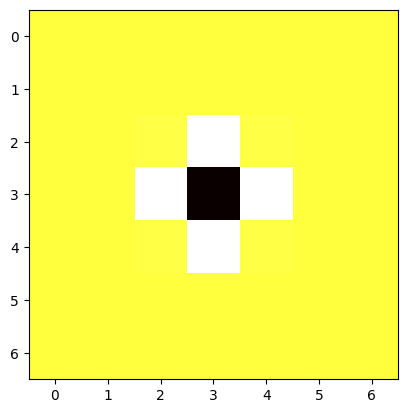

In [ ]:
plt.imshow(result2[1].weight.detach().cpu(), cmap='hot')
plt.show()

In [ ]:
print(result2[1].weight)

Parameter containing:
tensor([[ 3.1161e-03, -1.3484e-02,  2.2250e-02, -2.8141e-02,  1.7618e-02,
         -3.3582e-03, -2.2505e-03],
        [-8.3467e-03,  1.1806e-01, -5.1945e-01,  7.0139e-01, -2.2035e-01,
          1.1376e-02,  4.3274e-04],
        [ 5.9656e-03, -3.8590e-01,  6.8175e+00,  3.8992e+01,  5.2822e+00,
         -9.6959e-03, -3.8248e-03],
        [-1.7539e-02,  4.5534e-01,  3.9109e+01, -1.8063e+02,  3.9136e+01,
          4.5052e-01, -1.6429e-02],
        [-4.9344e-03, -2.9401e-03,  5.2410e+00,  3.9066e+01,  6.7584e+00,
         -3.9951e-01,  1.3251e-02],
        [-3.4400e-04,  9.2500e-03, -1.9816e-01,  6.5203e-01, -5.0077e-01,
          1.1985e-01, -8.6769e-03],
        [ 1.9449e-03, -5.6234e-03,  9.6823e-03, -2.0118e-02,  1.8027e-02,
         -1.0588e-02,  1.5362e-03]], requires_grad=True)


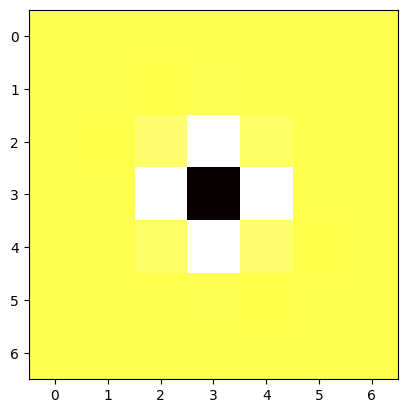

In [ ]:
plt.imshow(result2[1].weight.detach().cpu(), cmap='hot')
plt.show()

In [ ]:
EstblurVF = lambda x: EstimatedgaussblurIG(x, result[1].weight.detach().cpu())

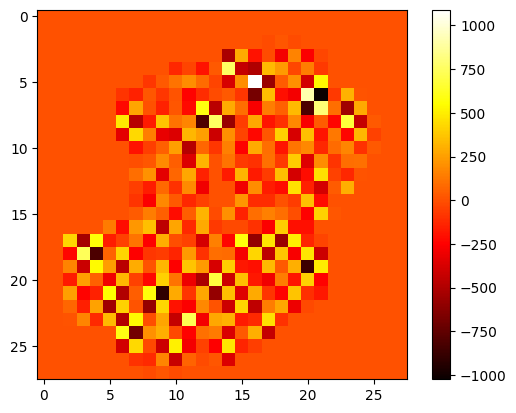

In [ ]:
im = plt.imshow(EstblurVF(gradient_list[7]).reshape((28,28)), cmap='hot')
plt.colorbar(im)
plt.show()

In [ ]:
terms = []
for i in range(60000):
    numer = torch.dot(blurVF(gradient_list[i]).reshape((28*28)), EstblurVF(gradient_list[i]).reshape((28*28)))
    d1 = torch.dot(blurVF(gradient_list[i]).reshape((28*28)), blurVF(gradient_list[i]).reshape((28*28)))
    d2 = torch.dot(EstblurVF(gradient_list[i]).reshape((28*28)), EstblurVF(gradient_list[i]).reshape((28*28)))

    terms.extend([numer/torch.sqrt(d1*d2)])
    if i % 5000==0:
        print("Done: " + str(i))

Done: 0
Done: 5000
Done: 10000
Done: 15000
Done: 20000
Done: 25000
Done: 30000
Done: 35000
Done: 40000
Done: 45000
Done: 50000
Done: 55000


In [ ]:
np.mean(terms)

np.float32(-0.0063882475)

In [ ]:
np.min(terms)

np.float32(-0.21274059)

In [ ]:
np.max(terms)

np.float32(0.31878018)

In [ ]:
terms2 = []
for i in range(60000):
    numer = torch.dot(gradient_list[i].reshape((28*28)), EstblurVF(gradient_list[i]).reshape((28*28)))
    d1 = torch.dot(gradient_list[i].reshape((28*28)), gradient_list[i].reshape((28*28)))
    d2 = torch.dot(EstblurVF(gradient_list[i]).reshape((28*28)), EstblurVF(gradient_list[i]).reshape((28*28)))

    terms2.extend([numer/torch.sqrt(d1*d2)])
    if i % 5000==0:
        print("Done: " + str(i))

Done: 0
Done: 5000
Done: 10000
Done: 15000
Done: 20000
Done: 25000
Done: 30000
Done: 35000
Done: 40000
Done: 45000
Done: 50000
Done: 55000


In [ ]:
np.mean(terms2)

np.float32(-0.12919499)

In [ ]:
np.min(terms2)

np.float32(-0.4181767)

In [ ]:
np.max(terms2)

np.float32(0.23104313)

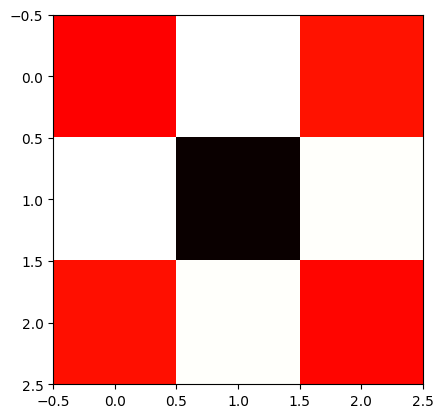

In [ ]:
plt.imshow(result[1].weight.detach().cpu(), cmap='hot')
plt.show()

In [ ]:
GTkernel = torch.tensor([
                           [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)],
                           [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
                           [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
                           [6.347132048*10**(-20),3.245999951*10**(-8),0.1388299687,-0.5596471072,0.1388299687,3.245999951*10**(-8),6.347132048*10**(-20)],
                           [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
                           [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
                           [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)]])
GTkernel

tensor([[ 2.4600e-41,  2.0486e-29,  2.7267e-22,  6.3471e-20,  2.7267e-22,
          2.0486e-29,  2.4600e-41],
        [ 2.0486e-29,  1.4529e-17,  1.5698e-10,  3.2460e-08,  1.5698e-10,
          1.4529e-17,  2.0486e-29],
        [ 2.7267e-22,  1.5698e-10,  1.0818e-03,  1.3883e-01,  1.0818e-03,
          1.5698e-10,  2.7267e-22],
        [ 6.3471e-20,  3.2460e-08,  1.3883e-01, -5.5965e-01,  1.3883e-01,
          3.2460e-08,  6.3471e-20],
        [ 2.7267e-22,  1.5698e-10,  1.0818e-03,  1.3883e-01,  1.0818e-03,
          1.5698e-10,  2.7267e-22],
        [ 2.0486e-29,  1.4529e-17,  1.5698e-10,  3.2460e-08,  1.5698e-10,
          1.4529e-17,  2.0486e-29],
        [ 2.4600e-41,  2.0486e-29,  2.7267e-22,  6.3471e-20,  2.7267e-22,
          2.0486e-29,  2.4600e-41]])

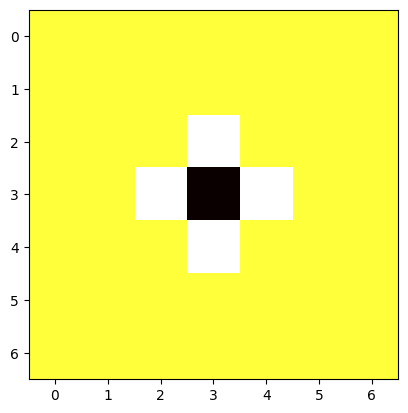

In [ ]:
#plt.imshow(GTkernel, cmap='hot')
#plt.show()